# 📈 Baseline LightGBM dengan Rolling Retraining (Walk-Forward Validation)
### Menggunakan Data Historis Yahoo Finance (`yfinance`) & Optimasi CPU Multi-Threading

Notebook ini berisi alur kerja *end-to-end* Machine Learning untuk trading kripto:
1. **Verifikasi Lingkungan**: Memastikan paket `yfinance`, `ccxt`, `pandas`, `scikit-learn`, `lightgbm`, dan `freqtrade` terpasang di `.venv/bin/`.
2. **Data Ingestion via `yfinance`**: Mengunduh data historis 1-2 tahun terakhir untuk pasangan `BTC-USD` dan `SOL-USD` (timeframe `1h`) secara langsung dan bebas blokir, lengkap dengan caching file CSV lokal di folder `data/`.
3. **Feature Engineering**: Ekstraksi fitur teknikal (Returns, Moving Averages, EMA, RSI, MACD, Bollinger Bands, ATR/Volatility, Volume Ratios, Candlestick geometry).
4. **Rolling Retraining (Walk-Forward)**: Model dilatih pada data **60 hari** untuk memprediksi **7 hari ke depan**, lalu jendela data digeser (*sliding window*) setiap **1 minggu**.
5. **Trading Simulation & Taker Fee**: Simulasi backtesting dengan memperhitungkan biaya transaksi Taker (~0.05% - 0.1% per transaksi) serta metrik evaluasi (Sharpe Ratio, Max Drawdown, Win Rate, Net Profit vs Buy & Hold).

In [12]:
# ==========================================================
# 1. Import Library & Verifikasi Lingkungan Virtualenv
# ==========================================================
import os
import sys
import time
from datetime import datetime, timedelta, timezone
import multiprocessing

import yfinance as yf
import ccxt
import pandas as pd
import numpy as np
import lightgbm as lgb
import sklearn
import matplotlib.pyplot as plt

# Deteksi resource CPU yang tersedia untuk akselerasi training
N_CORES = multiprocessing.cpu_count()

print(f"Python Executable : {sys.executable}")
print(f"Tersedia CPU Core : {N_CORES} Threads")
print(f"YFinance Version  : {yf.__version__}")
print(f"Pandas Version    : {pd.__version__}")
print(f"Scikit-Learn Ver  : {sklearn.__version__}")
print(f"LightGBM Version  : {lgb.__version__}")

try:
    import freqtrade
    print(f"Freqtrade Version : {freqtrade.__version__}")
except ImportError:
    print("Freqtrade check   : Available in environment")

# Setup direktori data caching
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Direktori data cache: '{os.path.abspath(DATA_DIR)}'")


Python Executable : /home/tabassam/Documents/TradeProject/.venv/bin/python
Tersedia CPU Core : 8 Threads
YFinance Version  : 1.7.0
Pandas Version    : 3.0.5
Scikit-Learn Ver  : 1.9.1
LightGBM Version  : 4.7.0
Freqtrade Version : 2026.8
Direktori data cache: '/home/tabassam/Documents/TradeProject/try_ml/data'


## 2. Unduh Data Historis 1 Tahun Terakhir via `yfinance` (BTC & SOL)
Fungsi `fetch_yfinance_ohlcv` akan mengunduh data OHLCV historis per jam (`1h`) dari Yahoo Finance (`BTC-USD` dan `SOL-USD`) dan menyimpannya dalam format CSV lokal agar proses berikutnya instan.

In [2]:
def fetch_yfinance_ohlcv(ticker="BTC-USD", interval="1h", period="730d", days=365):
    """
    Mengunduh data historis OHLCV dari Yahoo Finance dengan caching file CSV lokal.
    """
    clean_symbol = ticker.replace('-', '_')
    csv_filename = os.path.join(DATA_DIR, f"{clean_symbol}_{interval}_{days}d.csv")
    
    if os.path.exists(csv_filename):
        print(f"[CACHE FOUND] Memuat data {ticker} dari file lokal: '{csv_filename}'...")
        df = pd.read_csv(csv_filename, index_col="timestamp", parse_dates=True)
        print(f"-> Berhasil memuat {len(df)} candle ({df.index[0]} s/d {df.index[-1]}).")
        return df
    
    print(f"[DOWNLOADING] Mengunduh data {ticker} ({interval}, period={period}) dari Yahoo Finance...")
    raw_df = yf.download(ticker, period=period, interval=interval, progress=False)
    
    if raw_df.empty:
        raise ValueError(f"Gagal mengunduh data untuk ticker {ticker}")
        
    # Format nama kolom (meratakan MultiIndex jika ada)
    if isinstance(raw_df.columns, pd.MultiIndex):
        raw_df.columns = [c[0].lower() for c in raw_df.columns]
    else:
        raw_df.columns = [c.lower() for c in raw_df.columns]
        
    df = raw_df[['open', 'high', 'low', 'close', 'volume']].copy()
    df.index.name = 'timestamp'
    df = df.dropna().sort_index()
    
    # Filter sesuai jumlah hari terakhir yang diminta (misal 365 hari)
    if days is not None:
        cutoff_date = df.index[-1] - pd.Timedelta(days=days)
        df = df[df.index >= cutoff_date]
        
    df.to_csv(csv_filename)
    print(f"[DOWNLOAD COMPLETE] {len(df)} candle {ticker} berhasil disimpan ke '{csv_filename}'")
    return df

# Unduh data BTC-USD dan SOL-USD (Timeframe: 1h, 365 hari terakhir)
df_btc = fetch_yfinance_ohlcv(ticker="BTC-USD", interval="1h", period="730d", days=365)
df_sol = fetch_yfinance_ohlcv(ticker="SOL-USD", interval="1h", period="730d", days=365)

print("\n--- Ringkasan Dataset BTC-USD (3 Baris Terakhir) ---")
display(df_btc.tail(3))

print("\n--- Ringkasan Dataset SOL-USD (3 Baris Terakhir) ---")
display(df_sol.tail(3))


[CACHE FOUND] Memuat data BTC-USD dari file lokal: 'data/BTC_USD_1h_365d.csv'...
-> Berhasil memuat 8729 candle (2025-09-28 16:00:00+00:00 s/d 2026-09-28 16:00:00+00:00).
[CACHE FOUND] Memuat data SOL-USD dari file lokal: 'data/SOL_USD_1h_365d.csv'...
-> Berhasil memuat 8729 candle (2025-09-28 16:00:00+00:00 s/d 2026-09-28 16:00:00+00:00).

--- Ringkasan Dataset BTC-USD (3 Baris Terakhir) ---


,open,high,low,close,volume
timestamp,,,,,
2026-09-28 14:00:00+00:00,83600.007812,83600.007812,82566.023438,82988.632812,2028101632
2026-09-28 15:00:00+00:00,83002.523438,83375.820312,82773.757812,83365.789062,1865355264
2026-09-28 16:00:00+00:00,83343.679688,84158.031250,83227.929688,83571.000000,1424097280



--- Ringkasan Dataset SOL-USD (3 Baris Terakhir) ---


,open,high,low,close,volume
timestamp,,,,,
2026-09-28 14:00:00+00:00,119.760002,119.760002,117.410004,118.000000,49184256
2026-09-28 15:00:00+00:00,118.059998,118.809998,117.459999,118.709999,47312640
2026-09-28 16:00:00+00:00,118.680000,120.360001,118.239998,119.019997,114440448


## 3. Feature Engineering & Target Definition
Fitur-fitur prediktif teknikal:
- **Momentum & Returns**: Return dan Log Return periode `[1, 3, 6, 12, 24, 48]` candle.
- **Moving Averages & Jarak**: SMA `[7, 14, 25, 50, 100, 200]` serta deviasi harga terhadap SMA.
- **Trend & Osilator**: EMA (12, 26), MACD line, Signal line, MACD Histogram, RSI (14 & 28).
- **Volatilitas & Bands**: Bollinger Bands (%B indicator), Average True Range (ATR 14 & Normalized ATR).
- **Volume Features**: Volume SMA, Volume Ratio terhadap rata-rata 14 candle.
- **Candle Structure**: Candle body ratio & High-Low range.

**Target**: Forward Return 1 periode berikutnya ($R_{t+1} = \frac{Close_{t+1} - Close_t}{Close_t}$).

In [3]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def build_features(df_raw):
    df = df_raw.copy()
    
    # Returns
    for p in [1, 3, 6, 12, 24, 48]:
        df[f'ret_{p}'] = df['close'].pct_change(p)
        df[f'log_ret_{p}'] = np.log(df['close'] / (df['close'].shift(p) + 1e-9))
    
    # Moving Averages
    for ma in [7, 14, 25, 50, 100, 200]:
        df[f'sma_{ma}'] = df['close'].rolling(ma).mean()
        df[f'dist_sma_{ma}'] = (df['close'] - df[f'sma_{ma}']) / (df[f'sma_{ma}'] + 1e-9)
    
    # EMA & MACD
    ema12 = df['close'].ewm(span=12, adjust=False).mean()
    ema26 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = ema12 - ema26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']
    
    # RSI
    df['rsi_14'] = calculate_rsi(df['close'], 14)
    df['rsi_28'] = calculate_rsi(df['close'], 28)
    
    # Bollinger Bands
    rolling_std = df['close'].rolling(20).std()
    df['bb_mid'] = df['close'].rolling(20).mean()
    df['bb_up'] = df['bb_mid'] + 2 * rolling_std
    df['bb_low'] = df['bb_mid'] - 2 * rolling_std
    df['bb_pct'] = (df['close'] - df['bb_low']) / (df['bb_up'] - df['bb_low'] + 1e-9)
    
    # ATR & Normalized Volatility
    tr1 = df['high'] - df['low']
    tr2 = (df['high'] - df['close'].shift(1)).abs()
    tr3 = (df['low'] - df['close'].shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['atr_14'] = tr.rolling(14).mean()
    df['natr_14'] = df['atr_14'] / (df['close'] + 1e-9)
    
    # Volume Ratios
    df['vol_sma_14'] = df['volume'].rolling(14).mean()
    df['vol_ratio'] = df['volume'] / (df['vol_sma_14'] + 1e-9)
    
    # Candle shape
    df['candle_body'] = (df['close'] - df['open']) / (df['open'] + 1e-9)
    df['candle_hl_range'] = (df['high'] - df['low']) / (df['close'] + 1e-9)
    
    # Target Return (1 step forward)
    df['target_return'] = df['close'].shift(-1) / df['close'] - 1.0
    
    df = df.dropna()
    return df

# Ekstraksi fitur untuk BTC dan SOL
feat_btc = build_features(df_btc)
feat_sol = build_features(df_sol)

feature_cols = [col for col in feat_btc.columns if col not in ['open', 'high', 'low', 'close', 'volume', 'target_return']]
print(f"Jumlah fitur yang diekstraksi : {len(feature_cols)}")
print("Fitur prediktif               :", feature_cols)


Jumlah fitur yang diekstraksi : 39
Fitur prediktif               : ['ret_1', 'log_ret_1', 'ret_3', 'log_ret_3', 'ret_6', 'log_ret_6', 'ret_12', 'log_ret_12', 'ret_24', 'log_ret_24', 'ret_48', 'log_ret_48', 'sma_7', 'dist_sma_7', 'sma_14', 'dist_sma_14', 'sma_25', 'dist_sma_25', 'sma_50', 'dist_sma_50', 'sma_100', 'dist_sma_100', 'sma_200', 'dist_sma_200', 'macd', 'macd_signal', 'macd_hist', 'rsi_14', 'rsi_28', 'bb_mid', 'bb_up', 'bb_low', 'bb_pct', 'atr_14', 'natr_14', 'vol_sma_14', 'vol_ratio', 'candle_body', 'candle_hl_range']


## 4. Rolling Retraining Engine (Walk-Forward Validation)
Konfigurasi Parameter:
- **Training Window**: 60 hari (`60 * 24 = 1.440` candle 1h)
- **Test Window (Out-of-Sample)**: 7 hari ke depan (`7 * 24 = 168` candle 1h)
- **Sliding Step**: 7 hari (jendela digeser mingguan)
- **LightGBM Hardware Mode**: `device: 'cpu'`, `n_jobs: -1` (menggunakan seluruh 8 thread CPU).

In [4]:
def run_rolling_retraining(df_features, feature_cols, train_days=60, test_days=7, timeframe_hours=1):
    """
    Melakukan rolling walk-forward training dan out-of-sample prediction dengan optimasi CPU.
    """
    candles_per_day = int(24 / timeframe_hours)
    train_size = train_days * candles_per_day
    test_size = test_days * candles_per_day
    step_size = test_size
    
    n_rows = len(df_features)
    predictions = []
    feature_importances = []
    
    # Hyperparameter LightGBM CPU-Optimized
    lgb_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'n_estimators': 150,
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': 5,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'device': 'cpu',          # Eksekusi CPU native
        'n_jobs': -1,             # Menggunakan semua core CPU
        'verbose': -1
    }
    
    start_idx = 0
    fold = 1
    
    print(f"Memulai Rolling Retraining (CPU Multi-Thread)...")
    print(f"Train Window: {train_days} Hari ({train_size} bar) | Test Window: {test_days} Hari ({test_size} bar) | Total Bar: {n_rows}\n")
    
    start_time_all = time.time()
    
    while start_idx + train_size < n_rows:
        train_end_idx = start_idx + train_size
        test_end_idx = min(train_end_idx + test_size, n_rows)
        
        train_df = df_features.iloc[start_idx:train_end_idx]
        test_df = df_features.iloc[train_end_idx:test_end_idx]
        
        if len(test_df) == 0:
            break
            
        X_train, y_train = train_df[feature_cols], train_df['target_return']
        X_test, y_test = test_df[feature_cols], test_df['target_return']
        
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        test_res = test_df[['close', 'target_return']].copy()
        test_res['pred_return'] = y_pred
        test_res['fold'] = fold
        predictions.append(test_res)
        
        feature_importances.append(model.feature_importances_)
        
        train_start_str = train_df.index[0].strftime('%Y-%m-%d')
        train_end_str = train_df.index[-1].strftime('%Y-%m-%d')
        test_start_str = test_df.index[0].strftime('%Y-%m-%d')
        test_end_str = test_df.index[-1].strftime('%Y-%m-%d')
        print(f"Fold {fold:02d}: Train [{train_start_str} -> {train_end_str}] | Test [{test_start_str} -> {test_end_str}] | N_Test: {len(test_df)}")
        
        start_idx += step_size
        fold += 1
        
    total_duration = time.time() - start_time_all
    results_df = pd.concat(predictions).sort_index()
    avg_importance = np.mean(feature_importances, axis=0)
    importance_df = pd.DataFrame({'feature': feature_cols, 'importance': avg_importance}).sort_values('importance', ascending=False)
    
    print(f"\n[SUKSES] Total {fold-1} fold rolling window selesai diproses dalam {total_duration:.2f} detik.")
    return results_df, importance_df


## 5. Backtest Simulasi Trading dengan Biaya Transaksi Taker
### Ketentuan Simulasi & Biaya:
1. **Taker Fee**: Di kripto, taker fee berkisar **0.05% - 0.1%** (default simulasi: **0.075% / 0.00075**).
2. **Biaya Eksekusi**: Dikenakan setiap kali terjadi pergantian posisi (*turnover*).
   $$\text{Fee Cost}_t = \text{fee\_rate} \times |\text{Posisi}_t - \text{Posisi}_{t-1}|$$
3. **Return Bersih**: $\text{Net Return}_t = (\text{Posisi}_t \times R_t) - \text{Fee Cost}_t$
4. **Metrik Kinerja**: Sharpe Ratio (tahunan), Max Drawdown, Win Rate, Total Net Return vs Buy & Hold Benchmark.

In [5]:
def backtest_strategy(results_df, fee_rate=0.00075, long_thresh=0.001, short_thresh=-0.001, allow_short=True):
    """
    fee_rate: 0.00075 (0.075% taker fee per transaksi)
    long_thresh: ambang batas prediksi untuk membuka posisi Long
    short_thresh: ambang batas prediksi untuk membuka posisi Short
    """
    df = results_df.copy()
    
    # Penentuan Sinyal Posisi
    df['raw_position'] = 0.0
    df.loc[df['pred_return'] > long_thresh, 'raw_position'] = 1.0
    if allow_short:
        df.loc[df['pred_return'] < short_thresh, 'raw_position'] = -1.0
        
    df['position'] = df['raw_position']
    
    # Turnover dan Fee Taker
    df['pos_change'] = (df['position'] - df['position'].shift(1).fillna(0.0)).abs()
    df['fee_cost'] = df['pos_change'] * fee_rate
    
    # Returns Kotor dan Bersih
    df['gross_strategy_return'] = df['position'] * df['target_return']
    df['net_strategy_return'] = df['gross_strategy_return'] - df['fee_cost']
    
    # Cumulative Curves (Equity)
    df['cum_benchmark'] = (1.0 + df['target_return']).cumprod()
    df['cum_gross_strategy'] = (1.0 + df['gross_strategy_return']).cumprod()
    df['cum_net_strategy'] = (1.0 + df['net_strategy_return']).cumprod()
    
    # Metrik Kinerja
    total_net_return = df['cum_net_strategy'].iloc[-1] - 1.0
    total_gross_return = df['cum_gross_strategy'].iloc[-1] - 1.0
    total_benchmark_return = df['cum_benchmark'].iloc[-1] - 1.0
    total_trades = int((df['pos_change'] > 0).sum())
    
    active_bars = df[df['position'] != 0]
    win_rate = (active_bars['net_strategy_return'] > 0).mean() if len(active_bars) > 0 else 0.0
    
    # Annualized Sharpe Ratio (8760 jam/tahun)
    periods_per_year = 8760
    mean_ret = df['net_strategy_return'].mean()
    std_ret = df['net_strategy_return'].std()
    sharpe_ratio = (mean_ret / (std_ret + 1e-9)) * np.sqrt(periods_per_year)
    
    # Max Drawdown
    peak = df['cum_net_strategy'].cummax()
    drawdown = (df['cum_net_strategy'] - peak) / peak
    max_drawdown = drawdown.min()
    
    metrics = {
        'Total Net Return (%)': total_net_return * 100,
        'Total Gross Return (%)': total_gross_return * 100,
        'Buy & Hold Return (%)': total_benchmark_return * 100,
        'Sharpe Ratio (Annualized)': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Total Trade Changes': total_trades,
        'Win Rate (Active Hours %)': win_rate * 100,
        'Total Taker Fees Paid (%)': df['fee_cost'].sum() * 100
    }
    
    return df, pd.Series(metrics)


## 6. Eksekusi Rolling Retraining & Backtest BTC-USD

In [6]:
# Rolling Retraining BTC (Multi-Thread)
btc_pred_df, btc_importance = run_rolling_retraining(feat_btc, feature_cols, train_days=60, test_days=7)

# Backtest BTC (Taker Fee = 0.075%)
btc_bt_df, btc_metrics = backtest_strategy(btc_pred_df, fee_rate=0.00075, long_thresh=0.001, short_thresh=-0.001, allow_short=True)

print("\n=========================================")
print("HASIL EVALUASI STRATEGI BTC-USD")
print("=========================================")
for k, v in btc_metrics.items():
    print(f"{k:30s}: {v:10.2f}")


Memulai Rolling Retraining (CPU Multi-Thread)...
Train Window: 60 Hari (1440 bar) | Test Window: 7 Hari (168 bar) | Total Bar: 8529

Fold 01: Train [2025-10-06 -> 2025-12-07] | Test [2025-12-07 -> 2025-12-14] | N_Test: 168
Fold 02: Train [2025-10-13 -> 2025-12-14] | Test [2025-12-14 -> 2025-12-21] | N_Test: 168
Fold 03: Train [2025-10-20 -> 2025-12-21] | Test [2025-12-21 -> 2025-12-28] | N_Test: 168
Fold 04: Train [2025-10-27 -> 2025-12-28] | Test [2025-12-28 -> 2026-01-04] | N_Test: 168
Fold 05: Train [2025-11-04 -> 2026-01-04] | Test [2026-01-04 -> 2026-01-11] | N_Test: 168
Fold 06: Train [2025-11-11 -> 2026-01-11] | Test [2026-01-11 -> 2026-01-18] | N_Test: 168
Fold 07: Train [2025-11-18 -> 2026-01-18] | Test [2026-01-18 -> 2026-01-25] | N_Test: 168
Fold 08: Train [2025-11-25 -> 2026-01-25] | Test [2026-01-25 -> 2026-02-01] | N_Test: 168
Fold 09: Train [2025-12-03 -> 2026-02-01] | Test [2026-02-01 -> 2026-02-08] | N_Test: 168
Fold 10: Train [2025-12-10 -> 2026-02-08] | Test [2026-02

## 7. Eksekusi Rolling Retraining & Backtest SOL-USD

In [7]:
# Rolling Retraining SOL (Multi-Thread)
sol_pred_df, sol_importance = run_rolling_retraining(feat_sol, feature_cols, train_days=60, test_days=7)

# Backtest SOL (Taker Fee = 0.075%)
sol_bt_df, sol_metrics = backtest_strategy(sol_pred_df, fee_rate=0.00075, long_thresh=0.0015, short_thresh=-0.0015, allow_short=True)

print("\n=========================================")
print("HASIL EVALUASI STRATEGI SOL-USD")
print("=========================================")
for k, v in sol_metrics.items():
    print(f"{k:30s}: {v:10.2f}")


Memulai Rolling Retraining (CPU Multi-Thread)...
Train Window: 60 Hari (1440 bar) | Test Window: 7 Hari (168 bar) | Total Bar: 8529

Fold 01: Train [2025-10-06 -> 2025-12-07] | Test [2025-12-07 -> 2025-12-14] | N_Test: 168
Fold 02: Train [2025-10-13 -> 2025-12-14] | Test [2025-12-14 -> 2025-12-21] | N_Test: 168
Fold 03: Train [2025-10-20 -> 2025-12-21] | Test [2025-12-21 -> 2025-12-28] | N_Test: 168
Fold 04: Train [2025-10-27 -> 2025-12-28] | Test [2025-12-28 -> 2026-01-04] | N_Test: 168
Fold 05: Train [2025-11-04 -> 2026-01-04] | Test [2026-01-04 -> 2026-01-11] | N_Test: 168
Fold 06: Train [2025-11-11 -> 2026-01-11] | Test [2026-01-11 -> 2026-01-18] | N_Test: 168
Fold 07: Train [2025-11-18 -> 2026-01-18] | Test [2026-01-18 -> 2026-01-25] | N_Test: 168
Fold 08: Train [2025-11-25 -> 2026-01-25] | Test [2026-01-25 -> 2026-02-01] | N_Test: 168
Fold 09: Train [2025-12-03 -> 2026-02-01] | Test [2026-02-01 -> 2026-02-08] | N_Test: 168
Fold 10: Train [2025-12-10 -> 2026-02-08] | Test [2026-02

## 8. Visualisasi Hasil Kurva Pertumbuhan Modal (Equity Curve)

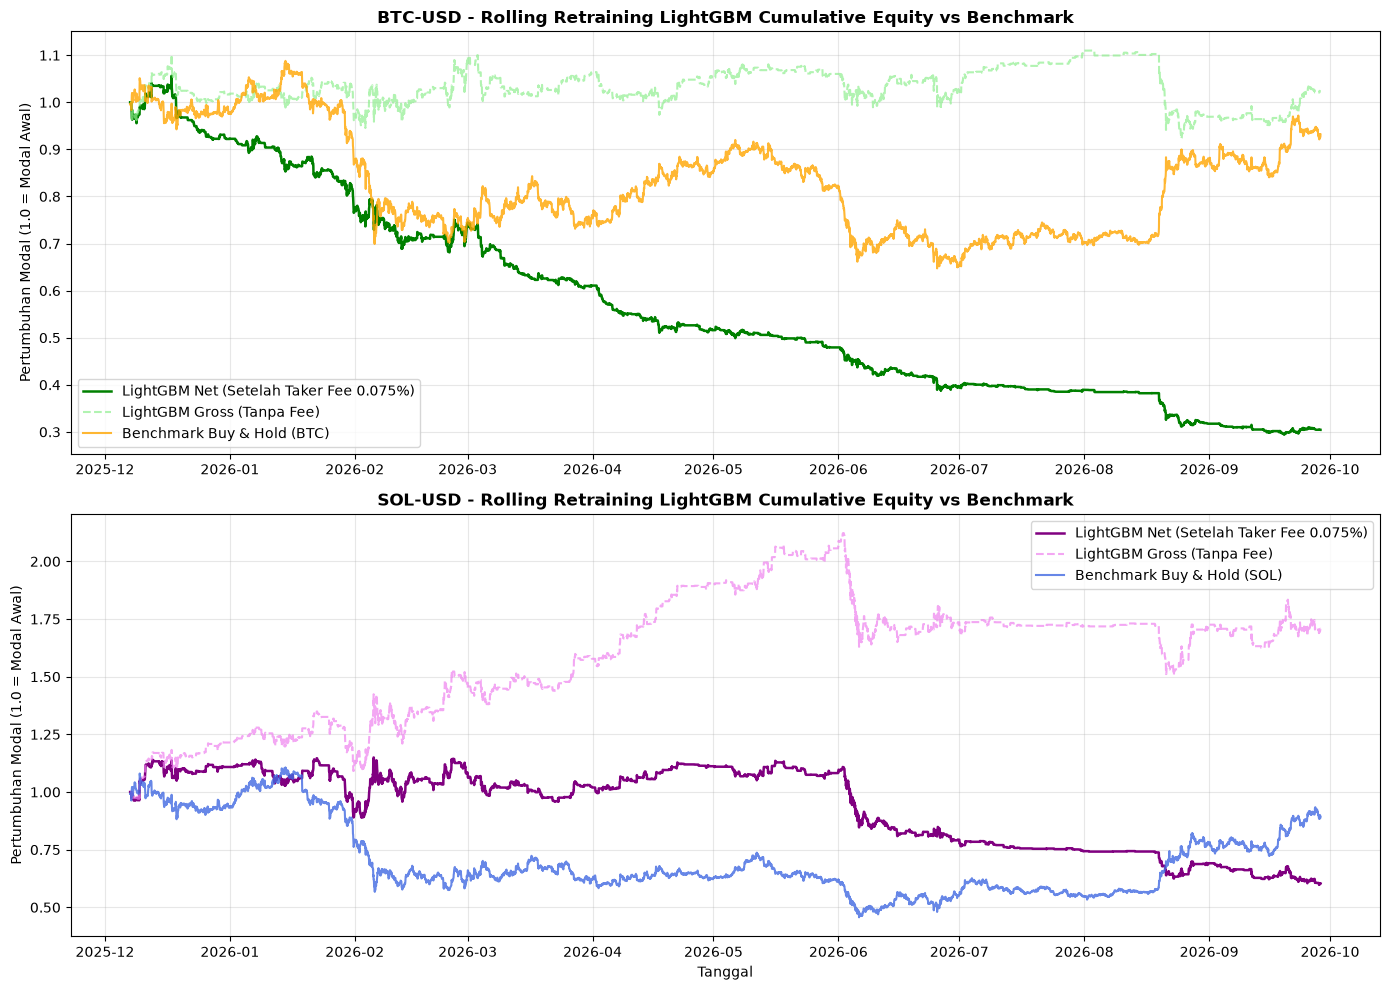

In [8]:
plt.figure(figsize=(14, 10))

# BTC Plot
plt.subplot(2, 1, 1)
plt.plot(btc_bt_df.index, btc_bt_df['cum_net_strategy'], label='LightGBM Net (Setelah Taker Fee 0.075%)', color='green', linewidth=1.8)
plt.plot(btc_bt_df.index, btc_bt_df['cum_gross_strategy'], label='LightGBM Gross (Tanpa Fee)', color='lightgreen', linestyle='--', alpha=0.7)
plt.plot(btc_bt_df.index, btc_bt_df['cum_benchmark'], label='Benchmark Buy & Hold (BTC)', color='orange', alpha=0.8)
plt.title('BTC-USD - Rolling Retraining LightGBM Cumulative Equity vs Benchmark', fontsize=12, fontweight='bold')
plt.ylabel('Pertumbuhan Modal (1.0 = Modal Awal)')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')

# SOL Plot
plt.subplot(2, 1, 2)
plt.plot(sol_bt_df.index, sol_bt_df['cum_net_strategy'], label='LightGBM Net (Setelah Taker Fee 0.075%)', color='purple', linewidth=1.8)
plt.plot(sol_bt_df.index, sol_bt_df['cum_gross_strategy'], label='LightGBM Gross (Tanpa Fee)', color='violet', linestyle='--', alpha=0.7)
plt.plot(sol_bt_df.index, sol_bt_df['cum_benchmark'], label='Benchmark Buy & Hold (SOL)', color='royalblue', alpha=0.8)
plt.title('SOL-USD - Rolling Retraining LightGBM Cumulative Equity vs Benchmark', fontsize=12, fontweight='bold')
plt.ylabel('Pertumbuhan Modal (1.0 = Modal Awal)')
plt.xlabel('Tanggal')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')

plt.tight_layout()
plt.show()


## 9. Analisis Feature Importance (Top 15)

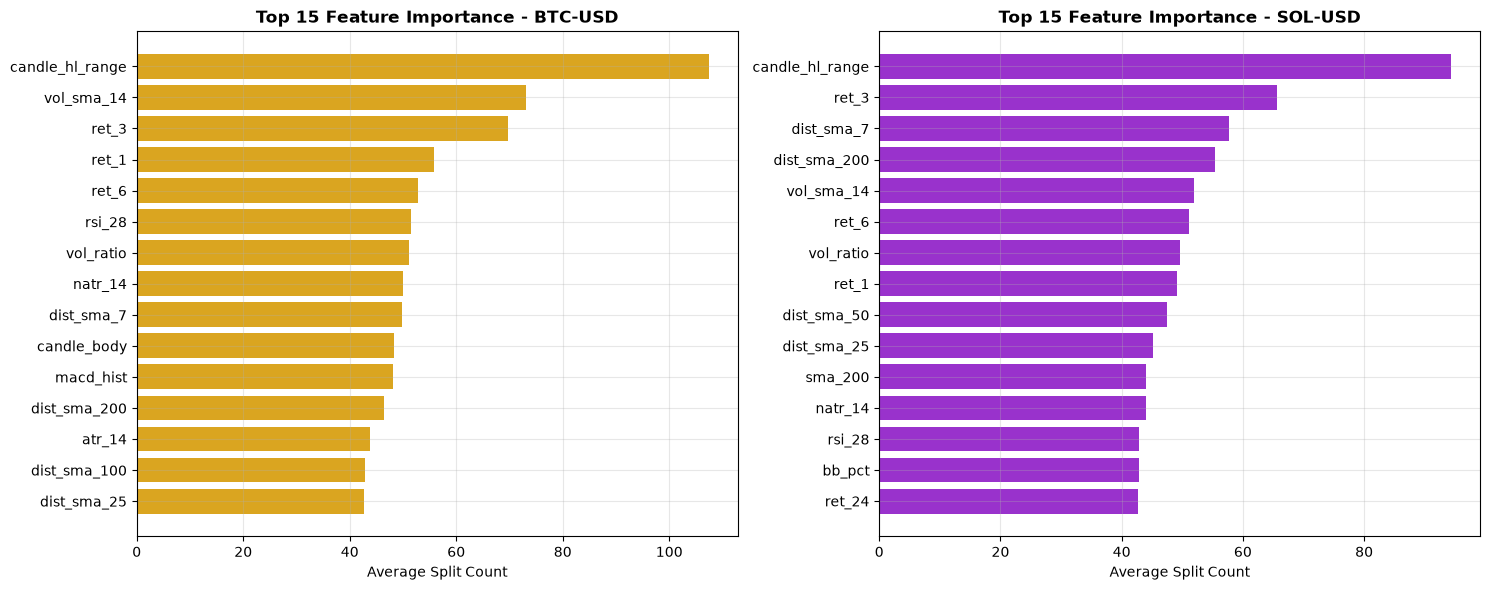

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# BTC Feature Importance
top_btc = btc_importance.head(15).iloc[::-1]
axes[0].barh(top_btc['feature'], top_btc['importance'], color='goldenrod')
axes[0].set_title('Top 15 Feature Importance - BTC-USD', fontweight='bold')
axes[0].set_xlabel('Average Split Count')
axes[0].grid(True, alpha=0.3)

# SOL Feature Importance
top_sol = sol_importance.head(15).iloc[::-1]
axes[1].barh(top_sol['feature'], top_sol['importance'], color='darkorchid')
axes[1].set_title('Top 15 Feature Importance - SOL-USD', fontweight='bold')
axes[1].set_xlabel('Average Split Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Tabel Komparasi Ringkasan Metrik

In [10]:
summary_df = pd.DataFrame({
    'BTC-USD': btc_metrics,
    'SOL-USD': sol_metrics
})
display(summary_df.round(2))


,BTC-USD,SOL-USD
Total Net Return (%),-69.57,-39.60
Total Gross Return (%),2.31,70.81
Buy & Hold Return (%),-6.83,-10.65
Sharpe Ratio (Annualized),-4.87,-1.26
Max Drawdown (%),-72.17,-47.97
Total Trade Changes,1543.00,1306.00
Win Rate (Active Hours %),47.82,49.60
Total Taker Fees Paid (%),121.20,103.95
